# Маршрутизация тикетов ITSM / Customer Support

**Многозадачная NLP-задача:** предсказание **queue (52 класса)**, **priority (5 классов)** и **type (5 классов)**.

Цель
Построить модель, которая по тексту тикета предсказывает:

queue (52 класса) — основная задача (маршрутизация)  
priority (5 классов)  
type (5 классов): Incident / Request / Problem / Change / Unknown  
где Unknown = отсутствующая разметка type.

### Подходы
1. **TF-IDF + SGDClassifier** — базовая модель  
2. **Word2Vec-эмбеддинги + SGDClassifier**  
3. **Дообучение BGE-M3** для многозадачной классификации с использованием **HuggingFace Trainer + SDPA**

### Итоговая метрика

Score = 0.70 × Macro-F1(queue) + 0.15 × Accuracy(priority) + 0.15 × Accuracy(type)

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, f1_score, classification_report,confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
from gensim.models import Word2Vec
from tqdm import tqdm

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 0. Данные

In [2]:
DATASET = "Tobi-Bueck/customer-support-tickets"
ds = load_dataset(DATASET)
df_full = ds["train"].to_pandas()

DATA_DIR = '/kaggle/input/datasets/maksimleonov/nlp-homework1/'
train_idx = np.loadtxt('/kaggle/input/datasets/maksimleonov/nlp-homework1/train_idx.txt', dtype=np.int64)
val_idx = np.loadtxt('/kaggle/input/datasets/maksimleonov/nlp-homework1/val_idx.txt', dtype=np.int64)
test_idx = np.loadtxt('/kaggle/input/datasets/maksimleonov/nlp-homework1/test_idx.txt', dtype=np.int64)

df_train = df_full.iloc[train_idx].copy().reset_index(drop=True)
df_val = df_full.iloc[val_idx].copy().reset_index(drop=True)
df_test = df_full.iloc[test_idx].copy().reset_index(drop=True)

for d in [df_train, df_val, df_test]:
    d["type"] = d["type"].fillna("Unknown")


def make_text(df):
    return (df["subject"].fillna("") + " " + df["body"].fillna("")).astype(str)


df_train["text"] = make_text(df_train)
df_val["text"] = make_text(df_val)
df_test["text"] = make_text(df_test)

print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")
print(f"Columns: {list(df_full.columns)}")
df_train.head(3)

README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

Train: 49412, Val: 6176, Test: 6177
Columns: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,text
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None,Wesentlicher Sicherheitsvorfall Sehr geehrtes ...
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None,"Account Disruption Dear Customer Support Team,..."
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None,Query About Smart Home System Integration Feat...


---
## 1. Еда 

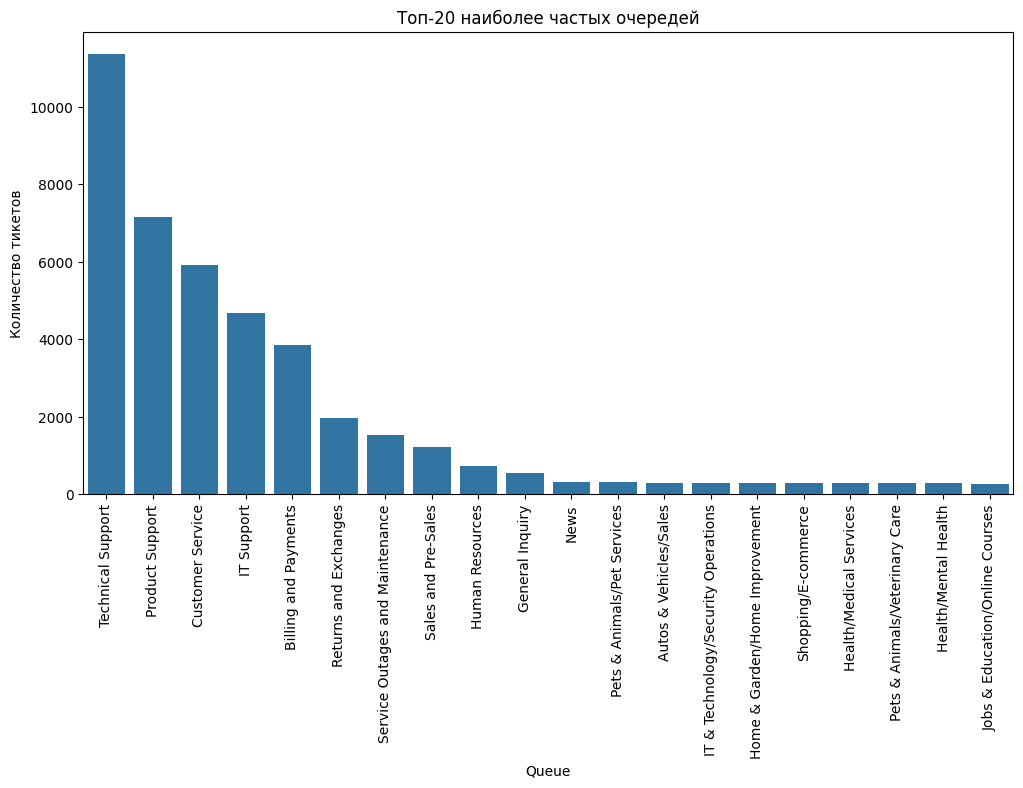

In [11]:
queue_counts = df_train["queue"].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=queue_counts.index[:20], y=queue_counts.values[:20])

plt.xticks(rotation=90)
plt.title("Топ-20 наиболее частых очередей")
plt.xlabel("Queue")
plt.ylabel("Количество тикетов")
plt.show()

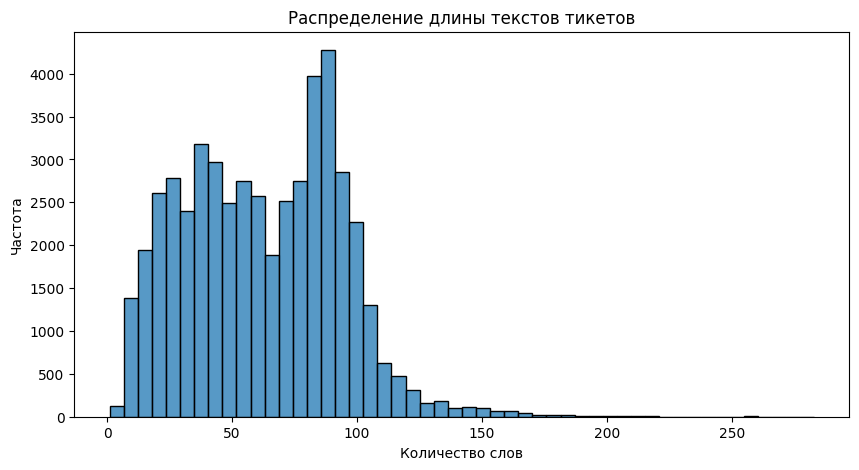

In [12]:
df_train["text_len"] = df_train["text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,5))
sns.histplot(df_train["text_len"], bins=50)

plt.title("Распределение длины текстов тикетов")
plt.xlabel("Количество слов")
plt.ylabel("Частота")
plt.show()

Text(0, 0.5, 'Число очередей')

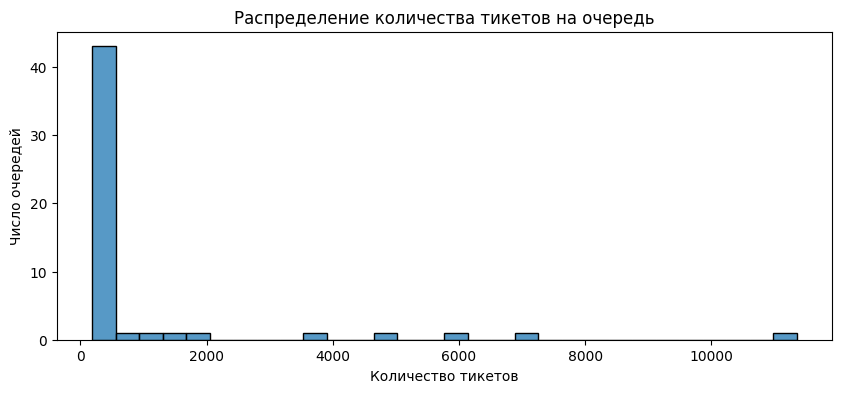

In [5]:
queue_counts = df_train["queue"].value_counts()

plt.figure(figsize=(10,4))
sns.histplot(queue_counts, bins=30)
plt.title("Распределение количества тикетов на очередь")
plt.xlabel("Количество тикетов")
plt.ylabel("Число очередей")

Большинство очередей имеют небольшое число тикетов, при этом несколько очередей содержат существенно больше данных. Это указывает на выраженный long-tail distribution, что может усложнять обучение модели.

Text(0.5, 1.0, 'Длина тикета в зависимости от priority')

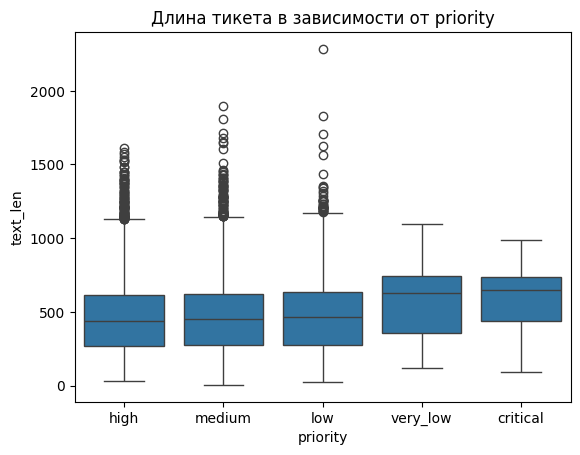

In [6]:
df_train["text_len"] = df_train["text"].str.len()

sns.boxplot(data=df_train, x="priority", y="text_len")
plt.title("Длина тикета в зависимости от priority")

<Axes: >

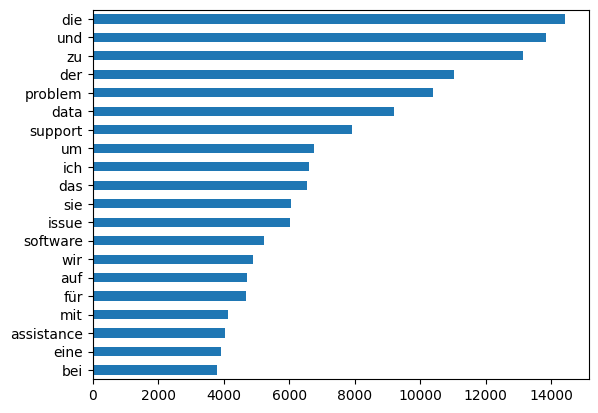

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

high_priority = df_train[df_train["priority"] == "high"]["text"]

vec = CountVectorizer(stop_words="english", max_features=20)
X = vec.fit_transform(high_priority)

pd.Series(X.sum(axis=0).A1, index=vec.get_feature_names_out()).sort_values().plot.barh()

<Axes: xlabel='queue', ylabel='type'>

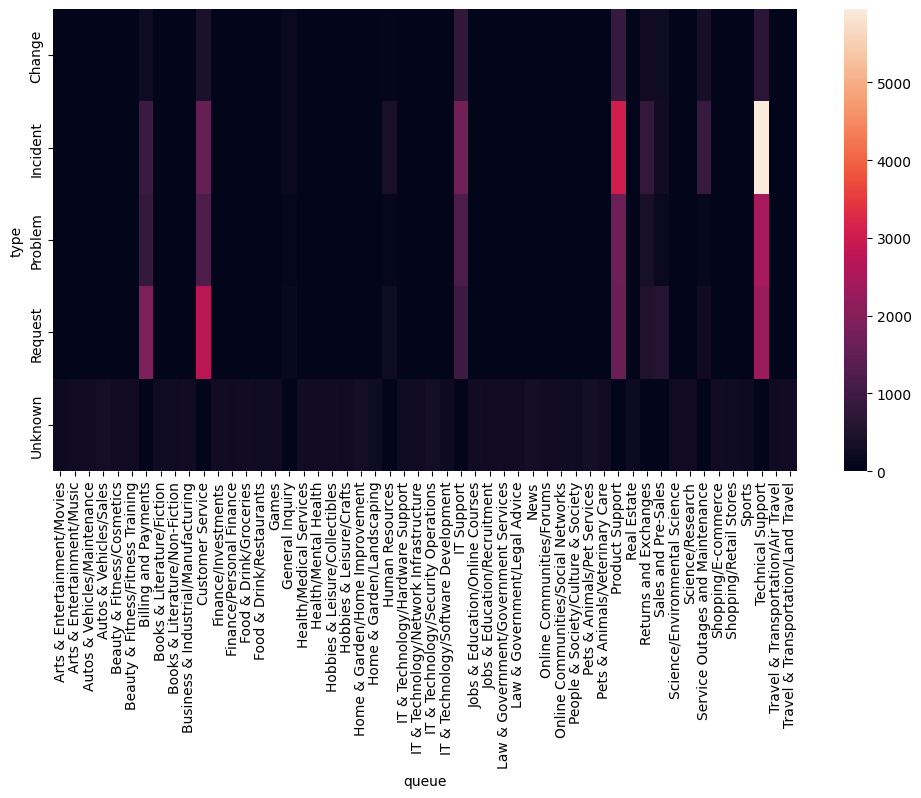

In [8]:
plt.figure(figsize=(12,6))
sns.heatmap(pd.crosstab(df_train["type"], df_train["queue"]))

<Axes: xlabel='unique_words', ylabel='Count'>

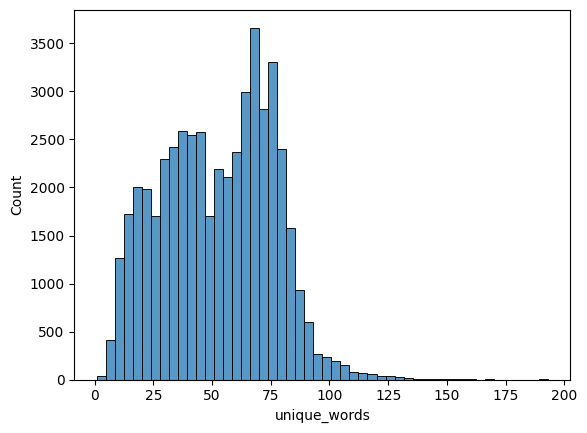

In [9]:
df_train["unique_words"] = df_train["text"].apply(lambda x: len(set(x.split())))

sns.histplot(df_train["unique_words"], bins=50)

<Axes: >

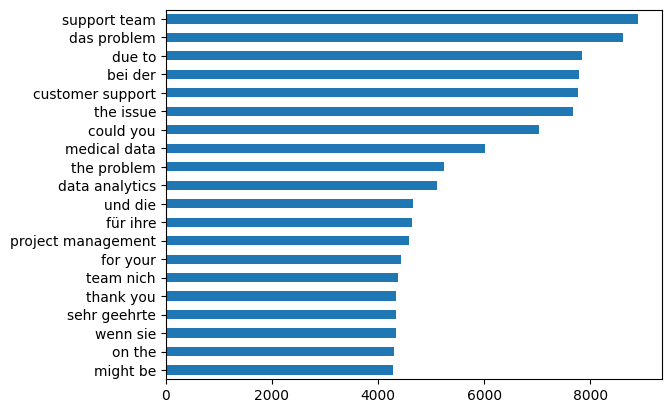

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer(ngram_range=(2,2), max_features=20)
X = vec.fit_transform(df_train["text"])

pd.Series(X.sum(axis=0).A1, index=vec.get_feature_names_out()).sort_values().plot.barh()

In [3]:
def compute_score(y_queue, pred_queue, y_priority, pred_priority, y_type, pred_type):
    macro_f1_queue = f1_score(y_queue, pred_queue, average="macro")
    accuracy_queue = accuracy_score(y_queue, pred_queue)
    accuracy_priority = accuracy_score(y_priority, pred_priority)
    accuracy_type = accuracy_score(y_type, pred_type)

    score = (
        0.70 * macro_f1_queue
        + 0.15 * accuracy_priority
        + 0.15 * accuracy_type
    )

    metrics = {
        "MacroF1(queue)": macro_f1_queue,
        "Acc(queue)": accuracy_queue,
        "Acc(priority)": accuracy_priority,
        "Acc(type)": accuracy_type,
        "Score": score,
    }
    return metrics


def print_results(results, model_name="Model"):
    line = "=" * 55

    print(f"\n{line}")
    print(f"  {model_name}")
    print(line)

    for metric_name, metric_value in results.items():
        print(f"  {metric_name:20s}: {metric_value:.4f}")

    print(line)


def confidence_coverage_analysis(
    y_true,
    y_pred,
    confidences,
    metric_fn,
    metric_name="Metric",
):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    confidences = np.asarray(confidences)

    ranking = np.argsort(confidences)[::-1]
    coverage_grid = np.arange(0.05, 1.01, 0.05)

    rows = []

    total = len(y_true)
    for coverage in coverage_grid:
        subset_size = max(1, int(total * coverage))
        chosen_idx = ranking[:subset_size]

        current_metric = metric_fn(y_true[chosen_idx], y_pred[chosen_idx])
        confidence_threshold = float(confidences[ranking[subset_size - 1]])

        rows.append(
            {
                "coverage": round(float(coverage), 2),
                "n_samples": subset_size,
                metric_name: round(float(current_metric), 4),
                "min_confidence": round(confidence_threshold, 4),
            }
        )

    return pd.DataFrame(rows)


def plot_confidence_curve(conf_df, metric_name, title, color="steelblue"):
    fig, ax_metric = plt.subplots(figsize=(10, 5))

    ax_metric.plot(
        conf_df["coverage"],
        conf_df[metric_name],
        marker="o",
        linestyle="-",
        color=color,
        linewidth=2,
        markersize=5,
        label=metric_name,
    )
    ax_metric.set_xlabel("Coverage")
    ax_metric.set_ylabel(metric_name, color=color)
    ax_metric.set_title(title)
    ax_metric.grid(alpha=0.3)

    ax_threshold = ax_metric.twinx()
    ax_threshold.plot(
        conf_df["coverage"],
        conf_df["min_confidence"],
        marker="s",
        linestyle="--",
        color="gray",
        alpha=0.6,
        linewidth=1,
        markersize=4,
        label="Min confidence",
    )
    ax_threshold.set_ylabel("Порог уверенности", color="gray")

    metric_lines, metric_labels = ax_metric.get_legend_handles_labels()
    threshold_lines, threshold_labels = ax_threshold.get_legend_handles_labels()

    ax_metric.legend(
        metric_lines + threshold_lines,
        metric_labels + threshold_labels,
        loc="lower right",
    )

    fig.tight_layout()
    plt.show()

## 2. TF-IDF

In [4]:
tfidf = TfidfVectorizer(max_features=200_000,ngram_range=(1,2),min_df=2,sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(df_train["text"])
X_val_tfidf = tfidf.transform(df_val["text"])
X_test_tfidf = tfidf.transform(df_test["text"])

In [5]:
tfidf_preds = {}
tfidf_probas = {}
all_model_results = {}
all_conf_curves = {}

targets = ["queue", "priority", "type"]

for target_name in targets:
    print(f"Training SGDClassifier for '{target_name}'...")

    sgd_model = SGDClassifier(
        loss="log_loss",
        alpha=1e-4,
        max_iter=100,
        tol=1e-3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    calibrated_model = CalibratedClassifierCV(
        sgd_model,
        cv=3,
        n_jobs=-1,
    )

    y_train = df_train[target_name].astype(str)
    y_test = df_test[target_name].astype(str)

    calibrated_model.fit(X_train_tfidf, y_train)

    predictions = calibrated_model.predict(X_test_tfidf)
    probabilities = calibrated_model.predict_proba(X_test_tfidf)

    tfidf_preds[target_name] = predictions
    tfidf_probas[target_name] = probabilities

    accuracy = accuracy_score(y_test, predictions)

    if target_name == "queue":
        macro_f1 = f1_score(y_test, predictions, average="macro")
        print(f"  {target_name}: Acc={accuracy:.4f}, MacroF1={macro_f1:.4f}")
    else:
        print(f"  {target_name}: Acc={accuracy:.4f}")

tfidf_results = compute_score(
    df_test["queue"].astype(str),
    tfidf_preds["queue"],
    df_test["priority"].astype(str),
    tfidf_preds["priority"],
    df_test["type"].astype(str),
    tfidf_preds["type"],
)

print_results(tfidf_results, "TF-IDF + SGDClassifier")
all_model_results["TF-IDF + SGD"] = tfidf_results

Training SGDClassifier for 'queue'...
  queue: Acc=0.5221, MacroF1=0.6936
Training SGDClassifier for 'priority'...
  priority: Acc=0.5707
Training SGDClassifier for 'type'...
  type: Acc=0.8452

  TF-IDF + SGDClassifier
  MacroF1(queue)      : 0.6936
  Acc(queue)          : 0.5221
  Acc(priority)       : 0.5707
  Acc(type)           : 0.8452
  Score               : 0.6979


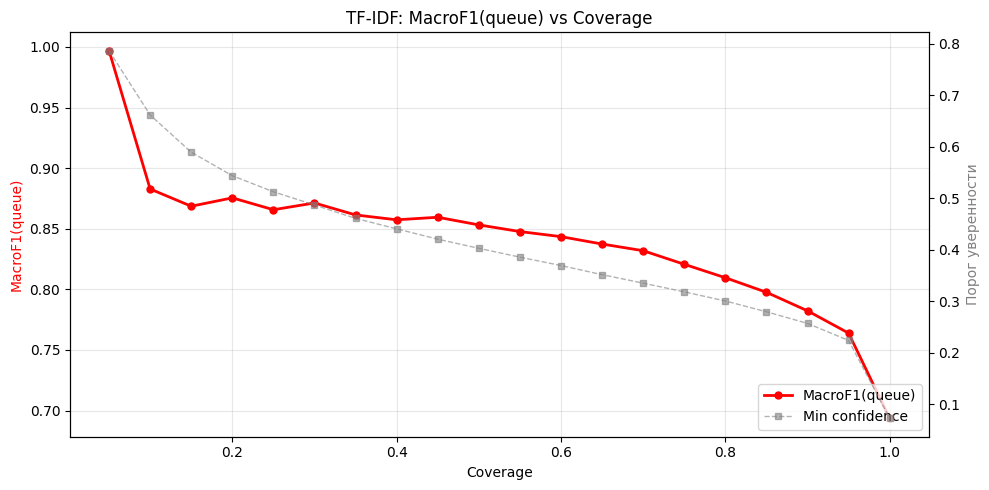

 coverage  n_samples  MacroF1(queue)  min_confidence
     0.05        308          0.9969          0.7867
     0.10        617          0.8828          0.6618
     0.15        926          0.8686          0.5896
     0.20       1235          0.8755          0.5439
     0.25       1544          0.8657          0.5127
     0.30       1853          0.8713          0.4871
     0.35       2161          0.8614          0.4610
     0.40       2470          0.8574          0.4407
     0.45       2779          0.8595          0.4206
     0.50       3088          0.8532          0.4029
     0.55       3397          0.8477          0.3857
     0.60       3706          0.8435          0.3694
     0.65       4015          0.8374          0.3517
     0.70       4323          0.8319          0.3352
     0.75       4632          0.8207          0.3183
     0.80       4941          0.8096          0.3006
     0.85       5250          0.7976          0.2796
     0.90       5559          0.7823          

In [6]:
tfidf_conf = confidence_coverage_analysis(
    df_test["queue"].astype(str).values,
    tfidf_preds["queue"],
    np.max(tfidf_probas["queue"], axis=1),
    lambda y, p: f1_score(y, p, average="macro"),
    "MacroF1(queue)",
)
all_conf_curves["TF-IDF + SGD"] = tfidf_conf

plot_confidence_curve(
    tfidf_conf,
    "MacroF1(queue)",
    "TF-IDF: MacroF1(queue) vs Coverage",
    color="red",
)
print(tfidf_conf.to_string(index=False))

## 3. Ворд2Век

In [8]:
def simple_tokenize(text):
    import re

    return re.findall(r"\w+", text.lower())


sentences_train = [simple_tokenize(t) for t in df_train["text"]]

w2v = Word2Vec(
    sentences_train,
    vector_size=300,
    window=5,
    min_count=2,
    workers=4,
    epochs=15,
    seed=RANDOM_STATE,
)
print(f"Word2Vec vocabulary: {len(w2v.wv)} words, dim={w2v.wv.vector_size}")

Word2Vec vocabulary: 23937 words, dim=300


In [9]:
def text_to_vec(text, model, dim=300):
    tokens = simple_tokenize(text)
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if not vecs:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)


print("Vectorizing train...")
X_train_w2v = np.array([text_to_vec(t, w2v) for t in tqdm(df_train["text"])])
print("Vectorizing val...")
X_val_w2v = np.array([text_to_vec(t, w2v) for t in tqdm(df_val["text"])])
print("Vectorizing test...")
X_test_w2v = np.array([text_to_vec(t, w2v) for t in tqdm(df_test["text"])])

print(f"W2V features shape: {X_train_w2v.shape}")

Vectorizing train...


100%|██████████| 49412/49412 [00:06<00:00, 7389.35it/s]


Vectorizing val...


100%|██████████| 6176/6176 [00:00<00:00, 7380.60it/s]


Vectorizing test...


100%|██████████| 6177/6177 [00:00<00:00, 7256.50it/s]

W2V features shape: (49412, 300)


In [10]:
w2v_preds = {}
w2v_probas = {}

for target in ["queue", "priority", "type"]:
    print(f"Training SGDClassifier (W2V) for '{target}'...")
    base = SGDClassifier(
        loss="log_loss",
        alpha=1e-4,
        max_iter=100,
        tol=1e-3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    clf = CalibratedClassifierCV(base, cv=3, n_jobs=-1)
    clf.fit(X_train_w2v, df_train[target].astype(str))

    w2v_preds[target] = clf.predict(X_test_w2v)
    w2v_probas[target] = clf.predict_proba(X_test_w2v)

    acc = accuracy_score(df_test[target].astype(str), w2v_preds[target])
    if target == "queue":
        mf1 = f1_score(df_test[target].astype(str), w2v_preds[target], average="macro")
        print(f"  {target}: Acc={acc:.4f}, MacroF1={mf1:.4f}")
    else:
        print(f"  {target}: Acc={acc:.4f}")

w2v_results = compute_score(
    df_test["queue"].astype(str),
    w2v_preds["queue"],
    df_test["priority"].astype(str),
    w2v_preds["priority"],
    df_test["type"].astype(str),
    w2v_preds["type"],
)
print_results(w2v_results, "Word2Vec + SGDClassifier")
all_model_results["Word2Vec + SGD"] = w2v_results

Training SGDClassifier (W2V) for 'queue'...
  queue: Acc=0.3341, MacroF1=0.1913
Training SGDClassifier (W2V) for 'priority'...
  priority: Acc=0.4879
Training SGDClassifier (W2V) for 'type'...
  type: Acc=0.8216

  Word2Vec + SGDClassifier
  MacroF1(queue)      : 0.1913
  Acc(queue)          : 0.3341
  Acc(priority)       : 0.4879
  Acc(type)           : 0.8216
  Score               : 0.3304


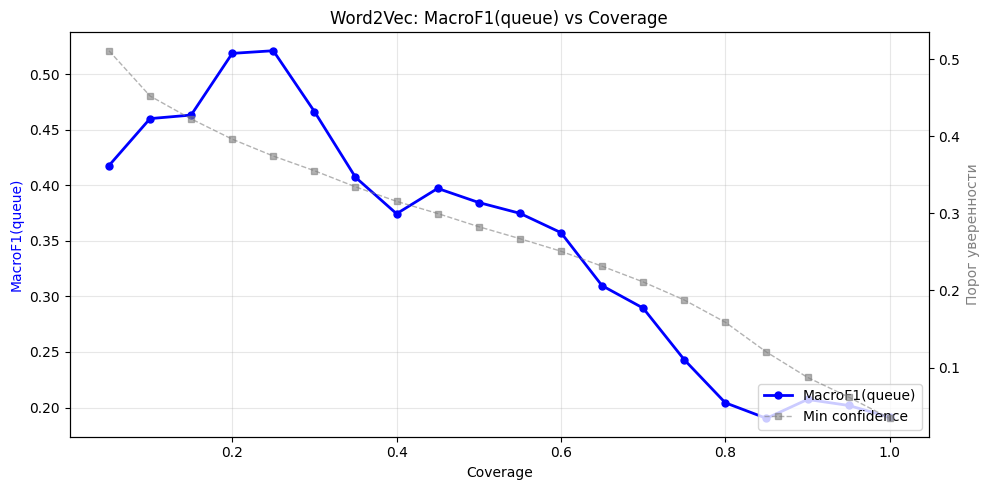

In [11]:
w2v_conf = confidence_coverage_analysis(
    df_test["queue"].astype(str).values,
    w2v_preds["queue"],
    np.max(w2v_probas["queue"], axis=1),
    lambda y, p: f1_score(y, p, average="macro"),
    "MacroF1(queue)",
)
all_conf_curves["Word2Vec + SGD"] = w2v_conf

plot_confidence_curve(
    w2v_conf, "MacroF1(queue)", "Word2Vec: MacroF1(queue) vs Coverage", color="blue"
)

## 4. XLM-RoBERTa based model


In [12]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, Trainer, TrainingArguments
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

MODEL_NAME = "xlm-roberta-base"
MAX_LEN = 256
BATCH_SIZE = 8
EPOCHS = 3
LR = 2e-5

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [13]:
label_encoders = {}
for target in ["queue", "priority", "type"]:
    le = LabelEncoder()
    le.fit(df_train[target].astype(str))
    label_encoders[target] = le
    for d in [df_train, df_val, df_test]:
        d[f"{target}_enc"] = le.transform(d[target].astype(str))

num_classes = {t: len(le.classes_) for t, le in label_encoders.items()}
print(f"Number of classes: {num_classes}")


class TicketDataset(Dataset):
    def __init__(self, texts, labels_dict, tokenizer, max_len):
        self.texts = texts
        self.labels = labels_dict
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels_queue"] = torch.tensor(self.labels["queue"][idx], dtype=torch.long)
        item["labels_priority"] = torch.tensor(
            self.labels["priority"][idx], dtype=torch.long
        )
        item["labels_type"] = torch.tensor(self.labels["type"][idx], dtype=torch.long)
        return item


def make_labels_dict(df):
    return {t: df[f"{t}_enc"].values for t in ["queue", "priority", "type"]}


train_ds = TicketDataset(
    df_train["text"].tolist(), make_labels_dict(df_train), tokenizer, MAX_LEN
)
val_ds = TicketDataset(
    df_val["text"].tolist(), make_labels_dict(df_val), tokenizer, MAX_LEN
)
test_ds = TicketDataset(
    df_test["text"].tolist(), make_labels_dict(df_test), tokenizer, MAX_LEN
)


Number of classes: {'queue': 52, 'priority': 5, 'type': 5}


In [14]:
class MultitaskTicketModel(nn.Module):
    def __init__(self, model_name, n_queue, n_priority, n_type, dropout=0.1):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(
            model_name,
            attn_implementation="sdpa",
        )
        h = self.backbone.config.hidden_size
        self.drop = nn.Dropout(dropout)
        self.head_queue = nn.Linear(h, n_queue)
        self.head_priority = nn.Linear(h, n_priority)
        self.head_type = nn.Linear(h, n_type)
        self.config = self.backbone.config

    def forward(
        self,
        input_ids,
        attention_mask,
        labels_queue=None,
        labels_priority=None,
        labels_type=None,
        **kwargs,
    ):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        cls_out = self.drop(out.last_hidden_state[:, 0, :])

        lq = self.head_queue(cls_out)
        lp = self.head_priority(cls_out)
        lt = self.head_type(cls_out)

        loss = None
        if labels_queue is not None:
            ce = nn.CrossEntropyLoss()
            loss = (
                0.70 * ce(lq.float(), labels_queue)
                + 0.15 * ce(lp.float(), labels_priority)
                + 0.15 * ce(lt.float(), labels_type)
            )

        return {
            "loss": loss,
            "logits_queue": lq,
            "logits_priority": lp,
            "logits_type": lt,
        }


class MultitaskTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        outputs = model(**inputs)
        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss


model = MultitaskTicketModel(
    MODEL_NAME,
    num_classes["queue"],
    num_classes["priority"],
    num_classes["type"],
)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters: 278,091,326


In [15]:
training_args = TrainingArguments(
    output_dir="./xlm_roberta_multitask_ckpt",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    learning_rate=LR,
    weight_decay=0.01,
    warmup_ratio=0.1,
    fp16=torch.cuda.is_available(),
    gradient_accumulation_steps=4,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=1,
    dataloader_num_workers=0,
    report_to="none",
    seed=RANDOM_STATE,
    remove_unused_columns=False,
)

trainer = MultitaskTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()
print("Training complete!")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss
1,1.356961,1.292999
2,1.171661,1.133674
3,1.076248,1.092505


Training complete!


In [21]:
model.eval()
model.to(device)

test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=0
)

test_preds_t = {t: [] for t in ["queue", "priority", "type"]}
test_probas_t = {t: [] for t in ["queue", "priority", "type"]}

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test evaluation"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        outputs = model(input_ids, attention_mask)
        for t in ["queue", "priority", "type"]:
            logits = outputs[f"logits_{t}"].float()
            probs = torch.softmax(logits, dim=1)
            test_preds_t[t].extend(logits.argmax(dim=1).cpu().numpy())
            test_probas_t[t].extend(probs.cpu().numpy())

transformer_preds = {}
transformer_probas = {}
for t in ["queue", "priority", "type"]:
    transformer_preds[t] = label_encoders[t].inverse_transform(test_preds_t[t])
    transformer_probas[t] = np.array(test_probas_t[t])

transformer_results = compute_score(
    df_test["queue"].astype(str),
    transformer_preds["queue"],
    df_test["priority"].astype(str),
    transformer_preds["priority"],
    df_test["type"].astype(str),
    transformer_preds["type"],
)
print_results(transformer_results, "BGE-M3 Multitask")
all_model_results["BGE-M3 Multitask"] = transformer_results

Test evaluation: 100%|██████████| 387/387 [00:16<00:00, 24.19it/s]


  BGE-M3 Multitask
  MacroF1(queue)      : 0.8897
  Acc(queue)          : 0.6689
  Acc(priority)       : 0.6037
  Acc(type)           : 0.8640
  Score               : 0.8430


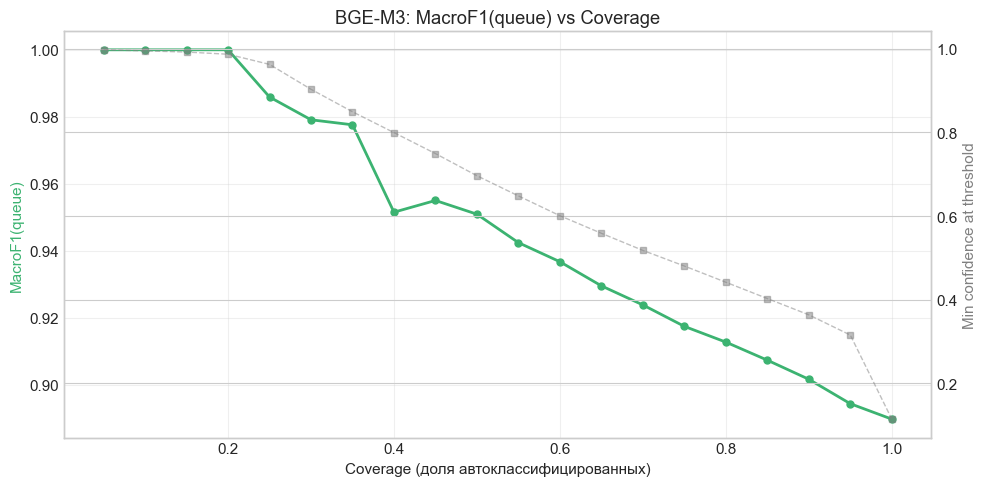

 coverage  n_samples  MacroF1(queue)  min_confidence
     0.05        308          1.0000          0.9979
     0.10        617          1.0000          0.9953
     0.15        926          1.0000          0.9925
     0.20       1235          1.0000          0.9873
     0.25       1544          0.9859          0.9630
     0.30       1853          0.9791          0.9034
     0.35       2161          0.9776          0.8496
     0.40       2470          0.9515          0.7997
     0.45       2779          0.9550          0.7495
     0.50       3088          0.9509          0.6965
     0.55       3397          0.9424          0.6482
     0.60       3706          0.9367          0.6008
     0.65       4015          0.9295          0.5587
     0.70       4323          0.9238          0.5178
     0.75       4632          0.9174          0.4804
     0.80       4941          0.9127          0.4416
     0.85       5250          0.9073          0.4026
     0.90       5559          0.9016          

In [22]:
transformer_conf = confidence_coverage_analysis(
    df_test["queue"].astype(str).values,
    transformer_preds["queue"],
    np.max(transformer_probas["queue"], axis=1),
    lambda y, p: f1_score(y, p, average="macro"),
    "MacroF1(queue)",
)
all_conf_curves["BGE-M3 Multitask"] = transformer_conf

plot_confidence_curve(
    transformer_conf,
    "MacroF1(queue)",
    "BGE-M3: MacroF1(queue) vs Coverage",
    color="mediumseagreen",
)
print(transformer_conf.to_string(index=False))

## 5. Итог

In [23]:
comparison_df = pd.DataFrame(all_model_results).T
comparison_df = comparison_df.round(4)
comparison_df = comparison_df.sort_values("Score", ascending=False)

print("=" * 70)
print("ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ (test set)")
print("=" * 70)
print(comparison_df.to_string())
print("=" * 70)
print(
    f"\nЛучшая модель по Score: {comparison_df['Score'].idxmax()} "
    f"({comparison_df['Score'].max():.4f})"
)
print(
    f"Тай-брейк MacroF1(queue): {comparison_df['MacroF1(queue)'].idxmax()} "
    f"({comparison_df['MacroF1(queue)'].max():.4f})"
)

ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ (test set)
                  MacroF1(queue)  Acc(queue)  Acc(priority)  Acc(type)   Score
BGE-M3 Multitask          0.8897      0.6689         0.6037     0.8640  0.8430
TF-IDF + SGD              0.6940      0.5224         0.5705     0.8451  0.6981
Word2Vec + SGD            0.1778      0.3304         0.4965     0.8190  0.3218

Лучшая модель по Score: BGE-M3 Multitask (0.8430)
Тай-брейк MacroF1(queue): BGE-M3 Multitask (0.8897)


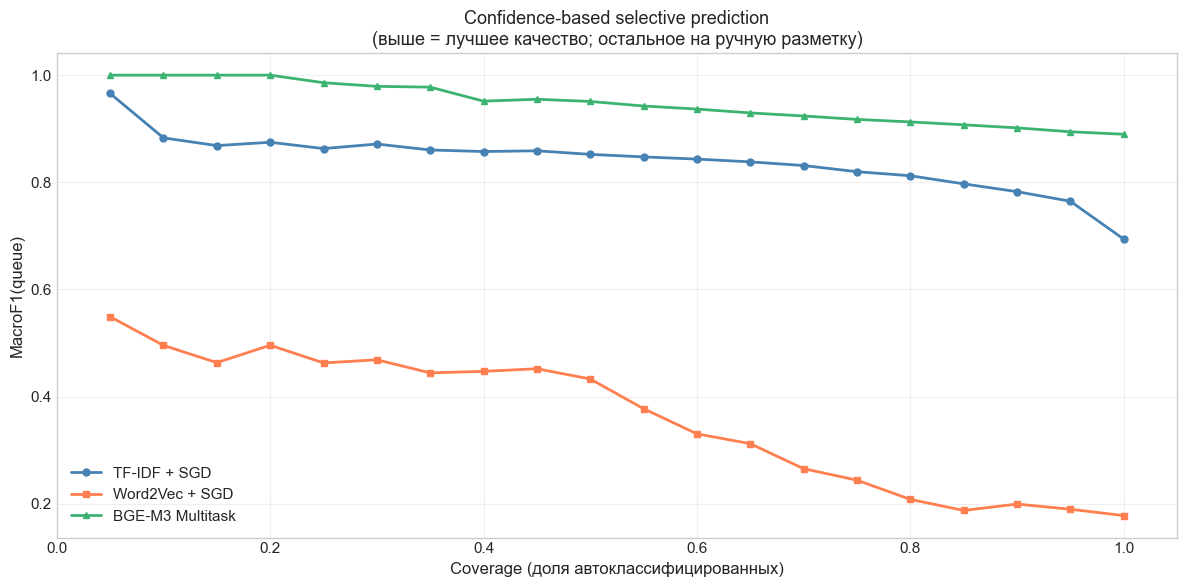


Key coverage points (MacroF1 on queue):
Coverage TF-IDF + SGD Word2Vec + SGD BGE-M3 Multitask
     50%       0.8521         0.4328           0.9509
     70%       0.8313         0.2653           0.9238
     80%       0.8122         0.2081           0.9127
     90%       0.7825         0.1993           0.9016
    100%       0.6940         0.1778           0.8897


In [24]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = {
    "TF-IDF + SGD": "steelblue",
    "Word2Vec + SGD": "coral",
    "BGE-M3 Multitask": "mediumseagreen",
}
markers = {"TF-IDF + SGD": "o", "Word2Vec + SGD": "s", "BGE-M3 Multitask": "^"}

for name, conf_df in all_conf_curves.items():
    ax.plot(
        conf_df["coverage"],
        conf_df["MacroF1(queue)"],
        f"{markers.get(name, 'o')}-",
        label=name,
        color=colors.get(name, "gray"),
        linewidth=2,
        markersize=5,
    )

ax.set_xlabel("Coverage (доля автоклассифицированных)", fontsize=12)
ax.set_ylabel("MacroF1(queue)", fontsize=12)
ax.set_title(
    "Confidence-based selective prediction\n"
    "(выше = лучшее качество; остальное на ручную разметку)",
    fontsize=13,
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()

print("\nKey coverage points (MacroF1 on queue):")
key_coverages = [0.5, 0.7, 0.8, 0.9, 1.0]
rows = []
for cov in key_coverages:
    row = {"Coverage": f"{cov:.0%}"}
    for name, conf_df in all_conf_curves.items():
        val = conf_df.loc[conf_df["coverage"] == round(cov, 2), "MacroF1(queue)"]
        row[name] = f"{val.values[0]:.4f}" if len(val) > 0 else "N/A"
    rows.append(row)
print(pd.DataFrame(rows).to_string(index=False))

---
## Выводы

TF-IDF + SGDClassifier показывает хороший скор, при этом быстро считается

Word2Vec + SGDClassifier показывает умеренные метрики. Основной недостаток подхода - усреднение векторов слов, из-за чего теряется информация о последовательности

XLM-RoBERTa Multitask достигает большего качества. Преимущества: контекстуальные эмбеддинги, учитывающие окружение токенов, и многозадачное обучение, позволяющее модели находить общие закономерности между задачами queue, priority и type.